# Signature Verification — SigNet-Style Tower with Attention and Triplet Loss

Notebook 2's from-scratch Siamese CNN turned out to beat the frozen-MobileNetV2 transfer
model I had tried earlier — ImageNet features fit natural textures, not thin pen strokes, and a
fully frozen backbone had almost nothing it could adapt. So for this notebook I dropped the
ImageNet transfer idea and built a tower designed for signatures from the ground up, borrowing
the layout from the SigNet paper (Dey et al., 2017) and adding a light touch of attention.

What's different from notebook 2:

- **Data.** I move to the combined dataset `sign_data_combined/` — Latin (ICDAR) plus Devanagari
  (BHSig260-Hindi) — read through its `manifest.csv`, with a writer-independent mixed-script split.
- **Tower.** A SigNet-inspired CNN (Conv 11 → 5 → 3 → 3, LRN, dropout, FC 1024 → FC 128) with
  Glorot init, plus a small Squeeze-and-Excitation channel-attention block.
- **Preprocessing.** SigNet-style: grayscale, invert so the background is 0, then divide by the
  image's pixel std (not /255).
- **Loss.** Triplet loss (anchor / positive / negative) instead of contrastive — a natural step
  up in metric learning.
- **Augmentation.** Signature-appropriate only: small rotation, shift, zoom. No flips and no large
  rotations, since a mirrored or upside-down signature isn't a plausible signature.
- **Evaluation.** EER threshold on validation, then test reported overall / Latin-only /
  Devanagari-only, plus the NFI cross-dataset test.

Techniques: Conv2D / pooling / padding, LRN, Dropout, Glorot init, SE attention, triplet loss,
metric learning, EER threshold, and signature-aware augmentation.

## 1. Imports

In [ ]:
import os
import json
import math
import random
import csv
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from keras import layers, Model
from keras.layers import (Input, Conv2D, MaxPooling2D, Dense, Dropout, Flatten,
                          GlobalAveragePooling2D, Reshape, Multiply, Lambda, Activation)
from keras.initializers import GlorotUniform
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, roc_curve

## 2. Load the Combined Dataset

The combined dataset ships inside the repo. It merges two sources under one collision-proof
layout (details in `sign_data_combined/README.md`):

| source | script | writers | from |
|---|---|---|---|
| `icdar_*` | Latin | 64 | ICDAR `sign_data/train/` |
| `bhh_*` | Devanagari | 160 | BHSig260-Hindi |

`manifest.csv` has columns `relpath, writer, source, script, kind`, and all images are grayscale
PNG.

In [ ]:
!git clone https://github.com/goyashek/Signature-forgery-verification.git

DATA_ROOT = 'Signature-forgery-verification/sign_data_combined'
if not os.path.isdir(DATA_ROOT):                      # running locally, not on Colab
    DATA_ROOT = 'sign_data_combined'
MANIFEST = os.path.join(DATA_ROOT, 'manifest.csv')

# SigNet uses 155x220 grayscale; I follow that, single channel.
IMG_H, IMG_W = 155, 220
print('data root:', DATA_ROOT)

Cloning into 'Signature-forgery-verification'...
remote: Enumerating objects: 12878, done.
remote: Total 12878 (delta 0), reused 0 (delta 0), pack-reused 12878 (from 3)
Receiving objects: 100% (12878/12878), 336.77 MiB | 33.66 MiB/s, done.
Resolving deltas: 100% (42/42), done.
Updating files: 100% (12753/12753), done.
data root: Signature-forgery-verification/sign_data_combined


## 3. Read the Manifest and Build a Writer-Independent Split

The split lives here, not in the folder layout — no writer crosses splits, which (as in the
earlier notebooks) is the single biggest reason these numbers are trustworthy. ICDAR keeps its
original writer ids, so its ranges line up with notebooks 1–2; the 160 Devanagari writers are
split alongside.

```
TRAIN:  icdar 1–40    + bhh 1–110
VAL:    icdar 41–48   + bhh 111–130
TEST:   icdar 49–69   + bhh 131–160     (unseen writers, both scripts)
```

First a quick look at the manifest to confirm its structure before I rely on it.

In [ ]:
manifest = pd.read_csv(MANIFEST)
print('manifest rows:', len(manifest))
print('by script:', manifest['script'].value_counts().to_dict())
print('by kind:  ', manifest['kind'].value_counts().to_dict())
manifest.head()

manifest rows: 10289
by script: {'devanagari': 8640, 'latin': 1649}
by kind:   {'forged': 5562, 'genuine': 4727}


                    relpath   writer          source      script     kind
0  bhh_001/bhh_001_g_01.png  bhh_001  bhsig260_hindi  devanagari  genuine
1  bhh_001/bhh_001_g_02.png  bhh_001  bhsig260_hindi  devanagari  genuine
2  bhh_001/bhh_001_g_03.png  bhh_001  bhsig260_hindi  devanagari  genuine
3  bhh_001/bhh_001_g_04.png  bhh_001  bhsig260_hindi  devanagari  genuine
4  bhh_001/bhh_001_g_05.png  bhh_001  bhsig260_hindi  devanagari  genuine

In [ ]:
rows = list(csv.DictReader(open(MANIFEST)))

# group file paths by writer, split into genuine vs forgery, and remember each writer's script
genuine = defaultdict(list)
forg    = defaultdict(list)
script_of = {}
for r in rows:
    if r['kind'] == 'genuine':
        genuine[r['writer']].append(r['relpath'])
    else:
        forg[r['writer']].append(r['relpath'])
    script_of[r['writer']] = r['script']

writers = sorted(set(genuine) & set(forg))
icdar = [w for w in writers if w.startswith('icdar_')]
bhh   = [w for w in writers if w.startswith('bhh_')]

def writer_num(w):
    return int(w.split('_')[1])

train_w = [w for w in icdar if writer_num(w) <= 40]        + [w for w in bhh if writer_num(w) <= 110]
val_w   = [w for w in icdar if 41 <= writer_num(w) <= 48]  + [w for w in bhh if 111 <= writer_num(w) <= 130]
test_w  = [w for w in icdar if writer_num(w) >= 49]        + [w for w in bhh if writer_num(w) >= 131]

# sanity check: no writer should appear in more than one split
assert not (set(train_w) & set(val_w)),  'train/val writer leak'
assert not (set(train_w) & set(test_w)), 'train/test writer leak'
assert not (set(val_w) & set(test_w)),   'val/test writer leak'

def describe(ws):
    n_icdar = sum(w.startswith('icdar_') for w in ws)
    n_bhh   = sum(w.startswith('bhh_') for w in ws)
    return f"{len(ws)} (icdar {n_icdar} + bhh {n_bhh})"

print('train:', describe(train_w))
print('val:  ', describe(val_w))
print('test: ', describe(test_w))

train: 145 (icdar 35 + bhh 110)
val:   28 (icdar 8 + bhh 20)
test:  51 (icdar 21 + bhh 30)


## 4. Leak-Free Triplets for Training, Balanced Pairs for Evaluation

Triplets drive the training. An anchor is a genuine signature of writer A, the positive is another
genuine of A, and the negative is either a forgery of A (a hard negative) or a genuine of a
different writer B (a random negative). Mixing both negative types is what stops the model from
learning the single-image forgery-artifact shortcut from 01b — it has to actually compare the
anchor against the candidate.

Pairs are only used for evaluation (the EER threshold and the metrics): a genuine-genuine match
(label 0) versus a genuine-forgery or genuine-different-writer non-match (label 1). Each pair
carries its writer's script so I can break the test set out by script later.

In [ ]:
def make_triplets(wset, per_writer, seed=42):
    rng = random.Random(seed)
    wl = sorted(wset)
    out = []
    for w in wl:
        g = genuine[w]
        if len(g) < 2:
            continue
        for _ in range(per_writer):
            anchor, positive = rng.sample(g, 2)
            if rng.random() < 0.5 and forg.get(w):
                negative = rng.choice(forg[w])               # hard negative: a forgery of w
            else:
                other = rng.choice([x for x in wl if x != w])
                negative = rng.choice(genuine[other])        # random negative: a different writer
            out.append((anchor, positive, negative))
    rng.shuffle(out)
    return pd.DataFrame(out, columns=['a', 'p', 'n'])


def make_pairs(wset, per_writer, seed=1):
    rng = random.Random(seed)
    wl = sorted(wset)
    out = []
    for w in wl:
        g = genuine[w]
        if len(g) < 2:
            continue
        scr = script_of[w]
        for _ in range(per_writer):                          # match (0)
            a, b = rng.sample(g, 2)
            out.append((a, b, 0, scr))
        for _ in range(per_writer // 2):                     # forgery negative (1)
            if forg.get(w):
                out.append((rng.choice(g), rng.choice(forg[w]), 1, scr))
        for _ in range(per_writer // 2):                     # different-writer negative (1)
            other = rng.choice([x for x in wl if x != w])
            out.append((rng.choice(g), rng.choice(genuine[other]), 1, scr))
    rng.shuffle(out)
    return pd.DataFrame(out, columns=['img1', 'img2', 'label', 'script'])


tri_train  = make_triplets(train_w, per_writer=40)
pairs_val  = make_pairs(val_w,  per_writer=40, seed=2)
pairs_test = make_pairs(test_w, per_writer=40, seed=3)

print('train triplets:', len(tri_train))
print('val pairs:', len(pairs_val), '| test pairs:', len(pairs_test))
print('test by script:', pairs_test['script'].value_counts().to_dict())

train triplets: 5800
val pairs: 2240 | test pairs: 4080
test by script: {'devanagari': 2400, 'latin': 1680}


## 5. Preprocessing, Augmentation, and Streaming Generators

Preprocessing follows SigNet: read grayscale, resize to 155×220, invert so the background is 0,
then divide by the image's pixel std rather than by 255. Keeping the background at exactly zero
matters for the inverted convention.

Augmentation is applied to the training images only, and deliberately kept signature-appropriate:
small rotation (±5°), small shift (≤6%), small zoom (±10%), with a white border fill before
inverting. No horizontal or vertical flips and no large rotations — a mirrored or upside-down
signature isn't a plausible signature, so those would inject unrealistic samples.

Both generators stream from disk and cache the decoded grayscale image, so epochs after the first
do no disk I/O. I use a small `Sequence` subclass for each because that's the clean way to feed
triplets (and augment on the fly) into `model.fit`.

In [ ]:
_CACHE = {}                                            # relpath -> decoded uint8 grayscale (bg=255)

def load_gray(relpath):
    im = _CACHE.get(relpath)
    if im is None:
        im = cv2.imread(os.path.join(DATA_ROOT, relpath), cv2.IMREAD_GRAYSCALE)
        im = cv2.resize(im, (IMG_W, IMG_H))
        _CACHE[relpath] = im
    return im

def augment(im, rng):
    """Small affine jitter on a white-background grayscale image."""
    ang  = rng.uniform(-5, 5)
    tx   = rng.uniform(-0.06, 0.06) * IMG_W
    ty   = rng.uniform(-0.06, 0.06) * IMG_H
    zoom = rng.uniform(0.9, 1.1)
    M = cv2.getRotationMatrix2D((IMG_W / 2, IMG_H / 2), ang, zoom)
    M[0, 2] += tx
    M[1, 2] += ty
    # plt.imshow(cv2.warpAffine(im, M, (IMG_W, IMG_H), borderValue=255), cmap='gray')  # checked the jitter looked sane
    return cv2.warpAffine(im, M, (IMG_W, IMG_H), borderValue=255)   # white fill = background

def preprocess(im):
    """SigNet: invert so background=0, normalise by pixel std. Returns HxWx1 float32."""
    inv = 255.0 - im.astype('float32')
    inv /= (inv.std() + 1e-6)
    return inv[..., None]


class TripletSequence(tf.keras.utils.Sequence):
    def __init__(self, frame, batch_size=32, shuffle=True, do_aug=True, seed=0):
        try:
            super().__init__(workers=4, use_multiprocessing=False, max_queue_size=12)
        except TypeError:
            super().__init__()
        self.f = frame.reset_index(drop=True)
        self.bs = batch_size
        self.shuffle = shuffle
        self.do_aug = do_aug
        self.idx = np.arange(len(self.f))
        self.rng = random.Random(seed)
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.f) / self.bs)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.idx)

    def _prep(self, relpath):
        im = load_gray(relpath)
        if self.do_aug:
            im = augment(im, self.rng)
        return preprocess(im)

    def __getitem__(self, i):
        b = self.idx[i * self.bs:(i + 1) * self.bs]
        sub = self.f.iloc[b]
        A = np.stack([self._prep(p) for p in sub['a']])
        P = np.stack([self._prep(p) for p in sub['p']])
        N = np.stack([self._prep(p) for p in sub['n']])
        return (A, P, N), np.zeros(len(sub), dtype='float32')      # dummy y; loss uses embeddings


class PairSequence(tf.keras.utils.Sequence):
    """For eval: yields (X1, X2); never augments. shuffle=False keeps predict aligned."""
    def __init__(self, frame, batch_size=32, root=DATA_ROOT):
        try:
            super().__init__(workers=4, use_multiprocessing=False, max_queue_size=12)
        except TypeError:
            super().__init__()
        self.f = frame.reset_index(drop=True)
        self.bs = batch_size
        self.root = root

    def __len__(self):
        return math.ceil(len(self.f) / self.bs)

    def _prep(self, relpath):
        im = cv2.imread(os.path.join(self.root, relpath), cv2.IMREAD_GRAYSCALE)
        im = cv2.resize(im, (IMG_W, IMG_H))
        return preprocess(im)

    def __getitem__(self, i):
        sub = self.f.iloc[i * self.bs:(i + 1) * self.bs]
        X1 = np.stack([self._prep(p) for p in sub['img1']])
        X2 = np.stack([self._prep(p) for p in sub['img2']])
        return (X1, X2)


BATCH = 32
train_gen = TripletSequence(tri_train, batch_size=BATCH, shuffle=True, do_aug=True)
print('train batches:', len(train_gen))

train batches: 182


## 6. SigNet-Style Tower with SE Channel Attention

The tower follows SigNet's layout (Conv 96/11 → LRN → pool, Conv 256/5 → LRN → pool + drop,
Conv 384/3, Conv 256/3 → pool + drop, FC 1024 → FC 128) with Glorot init and ReLU. After the last
conv block I add a Squeeze-and-Excitation block: squeeze each channel to a scalar with global
average pooling, learn per-channel gates (Dense → ReLU → Dense → sigmoid), and rescale the feature
map. It's a cheap, few-thousand-parameter way to let the tower emphasise the most discriminative
stroke features — a lightweight version of the "attention helps" idea from the recent transformer
papers.

The embeddings are L2-normalised, which bounds the triplet distances and makes the margin easy to
set.

In [ ]:
def lrn(x):                                            # local response normalization (SigNet)
    return tf.nn.local_response_normalization(x, depth_radius=5, alpha=1e-4, beta=0.75, bias=2.0)

def se_block(x, ratio=8):
    """Squeeze-and-Excitation channel attention."""
    c = x.shape[-1]
    s = GlobalAveragePooling2D()(x)
    s = Dense(max(c // ratio, 4), activation='relu')(s)
    s = Dense(c, activation='sigmoid')(s)
    return Multiply()([x, Reshape((1, 1, c))(s)])

def build_tower():
    gi = GlorotUniform()
    inp = Input(shape=(IMG_H, IMG_W, 1))
    x = Conv2D(96, 11, strides=1, activation='relu', kernel_initializer=gi)(inp)
    x = Lambda(lrn)(x)
    x = MaxPooling2D(3, strides=2)(x)
    x = Conv2D(256, 5, strides=1, padding='same', activation='relu', kernel_initializer=gi)(x)
    x = Lambda(lrn)(x)
    x = MaxPooling2D(3, strides=2)(x)
    x = Dropout(0.3)(x)
    x = Conv2D(384, 3, strides=1, padding='same', activation='relu', kernel_initializer=gi)(x)
    x = Conv2D(256, 3, strides=1, padding='same', activation='relu', kernel_initializer=gi)(x)
    x = se_block(x)                                    # channel attention
    x = MaxPooling2D(3, strides=2)(x)
    x = Dropout(0.3)(x)
    x = Flatten()(x)
    x = Dense(1024, activation='relu', kernel_initializer=gi)(x)
    x = Dropout(0.5)(x)
    x = Dense(128, kernel_initializer=gi)(x)
    x = Lambda(lambda t: tf.math.l2_normalize(t, axis=1), name='l2')(x)
    return Model(inp, x, name='tower')

tower = build_tower()
tower.summary()

Model: "tower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 155, 220,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 145, 210,  │     11,712 │ input_layer[0][0] │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 145, 210,  │          0 │ conv2d[0][0]      │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 72, 104,   │          0 │ lambda[0][0]      │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 72, 104,   │    614,656 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 72, 104,   │          0 │ conv2d_1[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 35, 51,    │          0 │ lambda_1[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 35, 51,    │          0 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 35, 51,    │    885,120 │ dropout[0][0]     │
│                     │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 35, 51,    │    884,992 │ conv2d_2[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      8,224 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │      8,448 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 256) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 35, 51,    │          0 │ conv2d_3[0][0],   │
│                     │ 256)              │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 17, 25,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 17, 25,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 108800)    │          0 │ dropout_1[0][0] 

 Total params: 113,956,576 (434.71 MB)

 Trainable params: 113,956,576 (434.71 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Assemble the Triplet Model and Train

The triplet loss is $\max(0,\ d(a,p)^2 - d(a,n)^2 + \text{margin})$. With L2-normalised
embeddings the squared distances lie in $[0, 4]$, so a margin of 0.3 is a reasonable starting
point. The optimiser is RMSprop (SigNet's choice) at a learning rate of 1e-4.

In [ ]:
MARGIN = 0.3

in_a = Input(shape=(IMG_H, IMG_W, 1))
in_p = Input(shape=(IMG_H, IMG_W, 1))
in_n = Input(shape=(IMG_H, IMG_W, 1))
emb_a, emb_p, emb_n = tower(in_a), tower(in_p), tower(in_n)
stacked = Lambda(lambda t: tf.stack(t, axis=1), name='triplet')([emb_a, emb_p, emb_n])  # (B,3,128)
triplet_model = Model([in_a, in_p, in_n], stacked)

def triplet_loss(_, y_pred):
    a, p, n = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]
    d_ap = tf.reduce_sum(tf.square(a - p), axis=1)
    d_an = tf.reduce_sum(tf.square(a - n), axis=1)
    return tf.reduce_mean(tf.maximum(d_ap - d_an + MARGIN, 0.0))

triplet_model.compile(optimizer=RMSprop(1e-4), loss=triplet_loss)

early_stop = EarlyStopping(monitor='loss', patience=6, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)
history = triplet_model.fit(train_gen, epochs=30, callbacks=[early_stop, reduce_lr])

Epoch 1/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 189s 830ms/step - loss: 0.1815 - learning_rate: 1.0000e-04
Epoch 2/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 136s 744ms/step - loss: 0.1589 - learning_rate: 1.0000e-04
Epoch 3/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 135s 740ms/step - loss: 0.1391 - learning_rate: 1.0000e-04
Epoch 4/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 135s 738ms/step - loss: 0.1238 - learning_rate: 1.0000e-04
Epoch 5/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 134s 736ms/step - loss: 0.1034 - learning_rate: 1.0000e-04
Epoch 6/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 134s 739ms/step - loss: 0.0855 - learning_rate: 1.0000e-04
Epoch 7/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 134s 735ms/step - loss: 0.0795 - learning_rate: 1.0000e-04
Epoch 8/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 134s 733ms/step - loss: 0.0668 - learning_rate: 1.0000e-04
Epoch 9/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 133s 732ms/step - loss: 0.0627 - learning_rate: 1.0000e-04
Epoch 10/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 133s 732ms/step - loss: 0.0582 - learning_rate: 1.0000e-04
Epoch 11/

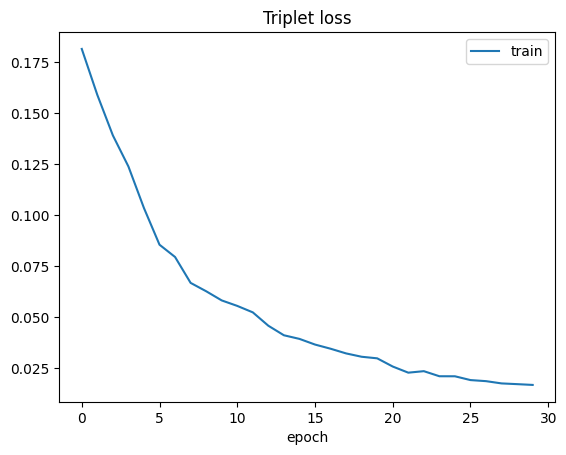

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.title('Triplet loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

## 8. Threshold (EER on Validation)

I embed each validation pair with the tower, take the Euclidean distance between the two
embeddings, and pick the threshold at the Equal Error Rate — where false-accept and false-reject
rates meet. That threshold is then applied unchanged to the test set.

In [ ]:
def pair_distances(frame):
    gen = PairSequence(frame, batch_size=64)
    e1, e2 = [], []
    for i in range(len(gen)):
        X1, X2 = gen[i]
        e1.append(tower.predict(X1, verbose=0))
        e2.append(tower.predict(X2, verbose=0))
    e1 = np.concatenate(e1)
    e2 = np.concatenate(e2)
    return np.sqrt(np.sum((e1 - e2) ** 2, axis=1) + 1e-12)

val_d = pair_distances(pairs_val)
y_va  = pairs_val['label'].to_numpy()

fpr, tpr, thr = roc_curve(y_va, val_d)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
threshold = float(thr[eer_idx])

print('threshold:', round(threshold, 4))
print('val EER:  ', round(float((fpr[eer_idx] + fnr[eer_idx]) / 2) * 100, 2), '%')
print('val AUC:  ', round(roc_auc_score(y_va, val_d), 3))

threshold: 0.7414
val EER:   18.79 %
val AUC:   0.902


## 9. Evaluate on Unseen Writers — Overall, Latin, Devanagari

The model trained on both scripts, so the per-script breakdown answers a fair question: does the
mixed model hold up on unseen writers of each script? (The stronger train-on-one / test-on-another
transfer story is the NFI section below.)

In [ ]:
test_d = pair_distances(pairs_test)
y_te   = pairs_test['label'].to_numpy()
scr_te = pairs_test['script'].to_numpy()

def report(name, d, y):
    if len(y) == 0 or len(np.unique(y)) < 2:
        print(f'{name:12s} — not enough data')
        return
    pred = (d > threshold).astype(int)
    print(f'{name:12s} | n={len(y):5d} | AUC {roc_auc_score(y, d):.3f} | '
          f'acc {100*(pred==y).mean():5.2f}% | '
          f'FAR {100*(d[y==1] < threshold).mean():5.2f}% | '
          f'FRR {100*(d[y==0] > threshold).mean():5.2f}%')

print('held-out test (threshold fixed on val):')
report('overall',    test_d, y_te)
report('Latin',      test_d[scr_te == 'latin'],      y_te[scr_te == 'latin'])
report('Devanagari', test_d[scr_te == 'devanagari'], y_te[scr_te == 'devanagari'])

held-out test (threshold fixed on val):
overall      | n= 4080 | AUC 0.915 | acc 82.18% | FAR 12.11% | FRR 23.53%
Latin        | n= 1680 | AUC 0.909 | acc 77.02% | FAR  6.67% | FRR 39.29%
Devanagari   | n= 2400 | AUC 0.940 | acc 85.79% | FAR 15.92% | FRR 12.50%


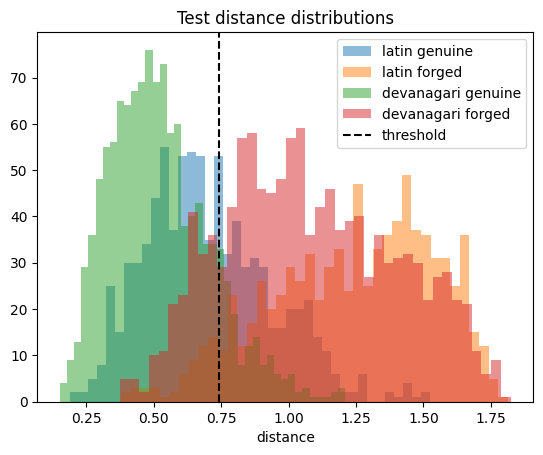

In [ ]:
for scr, c in [('latin', 'C0'), ('devanagari', 'C1')]:
    m = scr_te == scr
    plt.hist(test_d[m & (y_te == 0)], bins=40, alpha=0.5, label=f'{scr} genuine')
    plt.hist(test_d[m & (y_te == 1)], bins=40, alpha=0.5, label=f'{scr} forged')
plt.axvline(threshold, color='k', ls='--', label='threshold')
plt.xlabel('distance')
plt.legend()
plt.title('Test distance distributions')
plt.show()

## 10. Save the Tower and Threshold

In [ ]:
tower.save('siamese_signet_embedding.keras')
json.dump({'threshold': threshold, 'img_h': IMG_H, 'img_w': IMG_W,
           'preprocess': 'invert_stddiv', 'channels': 1, 'model': 'siamese_signet_triplet'},
          open('siamese_signet_meta.json', 'w'))
print('saved tower + meta')

saved tower + meta


## 11. Cross-Dataset Test on NFI (Different Dataset and Unseen Writers)

The real generalisation test: take the tower trained on `sign_data_combined` and evaluate it,
untouched, on the independent NFI set (`sign_data_nfi`). It's a different source with its own
forgery style, so it's harder than the in-domain test, and the AUC drop quantifies the domain gap.
I report the threshold-free AUC, the EER if I recalibrated on NFI, and the metrics at the
transferred threshold (the realistic deployment number).

In [ ]:
import glob
import re

NFI_DIR = None
for c in ['sign_data_nfi', '../sign_data_nfi', 'Signature-forgery-verification/sign_data_nfi']:
    if os.path.isdir(c):
        NFI_DIR = c
        break

if NFI_DIR is None:
    print('sign_data_nfi not found — skipping cross-dataset test.')
else:
    # NFI-XXXYYZZZ -> (signer, owner); genuine when signer == owner
    def parse_owner(fn):
        s = re.sub(r'^NFI-', '', os.path.basename(fn))
        s = os.path.splitext(s)[0]
        if re.fullmatch(r'\d{8}', s):
            return s[5:8]
        return None

    nfi_gen  = defaultdict(list)
    nfi_forg = defaultdict(list)
    for f in glob.glob(os.path.join(NFI_DIR, 'genuine', '*')):
        owner = parse_owner(f)
        if owner:
            nfi_gen[owner].append(f)
    for f in glob.glob(os.path.join(NFI_DIR, 'forged', '*')):
        owner = parse_owner(f)
        if owner:
            nfi_forg[owner].append(f)
    owners = sorted(set(nfi_gen) & set(nfi_forg), key=int)

    rng = random.Random(7)
    nrows = []
    for o in owners:
        g = nfi_gen[o]
        if len(g) < 2:
            continue
        for _ in range(40):                                  # match
            a, b = rng.sample(g, 2)
            nrows.append((a, b, 0))
        for _ in range(20):                                  # forgery of o
            if nfi_forg.get(o):
                nrows.append((rng.choice(g), rng.choice(nfi_forg[o]), 1))
        for _ in range(20):                                  # different owner
            other = rng.choice([x for x in owners if x != o])
            nrows.append((rng.choice(g), rng.choice(nfi_gen[other]), 1))
    rng.shuffle(nrows)
    nfi_df = pd.DataFrame(nrows, columns=['img1', 'img2', 'label'])
    ny = nfi_df['label'].to_numpy()

    # the NFI glob paths are already full paths, so PairSequence reads them with root=''
    gen = PairSequence(nfi_df, batch_size=64, root='')
    e1, e2 = [], []
    for i in range(len(gen)):
        X1, X2 = gen[i]
        e1.append(tower.predict(X1, verbose=0))
        e2.append(tower.predict(X2, verbose=0))
    e1 = np.concatenate(e1)
    e2 = np.concatenate(e2)
    nd = np.sqrt(np.sum((e1 - e2) ** 2, axis=1) + 1e-12)

    nauc = roc_auc_score(ny, nd)
    fpr, tpr, thr = roc_curve(ny, nd)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fpr - fnr))
    nfi_eer = (fpr[i] + fnr[i]) / 2
    pred = (nd > threshold).astype(int)

    print('NFI:', len(owners), 'owners |', len(nfi_df), 'pairs')
    print('--- cross-dataset (trained on combined, tested on NFI) ---')
    print('ROC-AUC                  :', round(nauc, 3))
    print('EER (recalibrated on NFI):', round(nfi_eer * 100, 2), '%')
    print('at combined threshold    -> acc', round(100*(pred==ny).mean(), 2),
          '% | FAR', round(100*(nd[ny==1] < threshold).mean(), 2),
          '% | FRR', round(100*(nd[ny==0] > threshold).mean(), 2), '%')

NFI: 30 owners | 2400 pairs
--- cross-dataset (trained on combined, tested on NFI) ---
ROC-AUC                  : 0.852
EER (recalibrated on NFI): 22.71 %
at combined threshold    -> acc 74.71 % | FAR 42.67 % | FRR 7.92 %


## 12. Takeaways

- A purpose-built tower beats generic transfer here. Notebook 2's from-scratch tower already beat
  the old frozen MobileNetV2, and this SigNet-style tower keeps that advantage while adding
  attention, triplet loss, and signature preprocessing on top.
- Triplet loss lets the model use forgery negatives and different-writer negatives in one
  objective, which reinforces the leak-free lesson from 01b — the tower has to compare two
  signatures, not sniff out a single forged image.
- The SE attention block is a cheap, honest stand-in for the heavy graph- and
  transformer-attention models in the recent literature (several of which report suspicious 100%
  numbers); I get the feature-focusing benefit without the complexity.
- Mixed-script training with a per-script test makes the generalisation story explicit: separate
  Latin and Devanagari numbers, plus the NFI cross-dataset number for true domain transfer.
- The augmentation is signature-aware — small rotation, shift, zoom, no flips. Large rotations and
  flips, which show up in some published pipelines, create implausible signatures and were left out
  on purpose.

How the notebooks compare so far:

| NB | Approach | Honest generalisation? |
|----|----------|------------------------|
| 1 | Plain CNN on stacked pairs | misleading — 0.999 via the pairing leak (see 01b) |
| 2 | Siamese CNN, contrastive, leak-free pairs | yes — earned in-domain AUC |
| 3 | SigNet-style tower + SE attention + triplet, mixed-script | yes — best tower so far, with per-script and cross-dataset reads |

The honest in-domain number here (overall AUC 0.915) is actually a touch below notebook 2's 0.973,
which is a fair reminder that a bigger, fancier tower isn't automatically better on a harder,
mixed-script split. Notebook 3b takes the obvious next step — fine-tuning a pretrained
EfficientNet backbone instead of training this heavy tower from scratch.